# TREC-DL attack table (LaTeX)

This notebook reads `attack_table.csv`, the dedicated `pointwise/pointwise.csv`, and `attack_outcomes.csv`, then writes `attack_table.tex`. Pointwise cells are accepted only from the new pointwise table; pairwise, setwise, and listwise DOH/DCH cells continue to come from `attack_table.csv`. It produces separate DOH, DCH, and Query Injection (QI) LaTeX tables. The QI table uses the normal evaluator prompt (**Default**) and the QI-specific defense (**Defense QI**). Each populated cell is rendered as `ASR%` and `successes/valid`.

The generated table requires `booktabs`, `makecell`, `multirow`, and `graphicx` in the manuscript preamble.


In [5]:
import csv
import re
import statistics
from collections import defaultdict
from pathlib import Path

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None
    display = None


def find_repository_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'LLM_prompt_attack').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')


def latex_escape(value):
    return (
        value.replace('\\', r'\textbackslash{}')
        .replace('&', r'\&')
        .replace('%', r'\%')
        .replace('_', r'\_')
        .replace('#', r'\#')
    )


METRIC = re.compile(r'^(?P<rate>\d+(?:\.\d+)?)% \((?P<success>\d+)/(?P<valid>\d+)\)$')
GROUPS = (
    ('Pointwise Attack Success %', 'Pointwise'),
    ('Pairwise Flipped %', 'Pairwise'),
    ('Setwise Attack Success %', 'Setwise'),
    ('Listwise Attack Top Position %', 'Listwise'),
)
ATTACKS = ('DOH', 'DCH')
MODES = (('Default', 'Ours'), ('Defense', 'Defense'))
QI_GROUPS = (
    ('Pairwise', 'Pairwise'),
    ('Setwise', 'Setwise'),
    ('Listwise', 'Listwise'),
)
QI_MODES = ('Default', 'Defense QI')
MODEL_LABELS = {
    'meta.llama3-70b-instruct-v1:0': 'Llama3-70B',
    'Llama3 70B': 'Llama3-70B',
    'Llama3-70B': 'Llama3-70B',
}
INCLUDED_MODELS = (
    'Qwen3-4B',
    'Qwen3-32B',
    'GPT-OSS-20B',
    'Llama-3-8B',
    'Llama3-70B',
)
MODEL_ORDER = {model: index for index, model in enumerate(INCLUDED_MODELS)}


def normalize_model(model):
    return MODEL_LABELS.get(model, model)


def column_name(group, attack, source):
    return f'{group} | {attack} | {source}'


def parse_metric(value):
    match = METRIC.match((value or '').strip())
    if match is None:
        return None
    return float(match['rate']), match['success'], match['valid']


def latex_metric(value):
    parsed = parse_metric(value)
    if parsed is None:
        return '--'
    rate, success, valid = parsed
    return rf'\makecell[c]{{{rate:.2f}\%\\[-1pt]\scriptsize({success}/{valid})}}'


def latex_summary(rows, column):
    values = [parsed[0] for row in rows if (parsed := parse_metric(row.get(column)))]
    if not values:
        return '--'
    if len(values) == 1:
        return rf'{values[0]:.2f}\%'
    return rf'{statistics.mean(values):.2f}\% $\pm$ {statistics.stdev(values):.2f}'


def metric_from_outcome(row):
    rate = float(row['Attack success (%)'])
    success = int(float(row['Attack success']))
    valid = int(float(row['Valid attacked']))
    return f'{rate:.2f}% ({success}/{valid})'



root = find_repository_root()
csv_path = root / 'Results' / 'attack_table.csv'
pointwise_path = root / 'Results' / 'pointwise' / 'pointwise.csv'
outcomes_path = root / 'Results' / 'attack_outcomes.csv'
tex_path = root / 'Results' / 'attack_table.tex'

with csv_path.open(encoding='utf-8', newline='') as csv_file:
    raw_rows = list(csv.DictReader(csv_file))

merged_rows = {}
for row in raw_rows:
    model = normalize_model(row['Model'])
    if model not in INCLUDED_MODELS:
        continue
    row = row.copy()
    for column in list(row):
        if column.startswith('Pointwise '):
            del row[column]
    row['Model'] = model
    key = (row['Dataset'], model)
    if key not in merged_rows:
        merged_rows[key] = row
    else:
        for column, value in row.items():
            if value and not merged_rows[key].get(column):
                merged_rows[key][column] = value
# Pointwise values come only from the dedicated new pointwise table.
# Do not source pointwise rows from attack_table.csv or attack_outcomes.csv.
if pointwise_path.exists():
    with pointwise_path.open(encoding='utf-8', newline='') as pointwise_file:
        for pointwise_row in csv.DictReader(pointwise_file):
            model = normalize_model(pointwise_row['Model'])
            if model not in INCLUDED_MODELS or pointwise_row['Attack'] not in ATTACKS:
                continue
            key = (pointwise_row['Dataset'], model)
            merged_rows.setdefault(key, {'Dataset': pointwise_row['Dataset'], 'Model': model})
            source = 'Defense' if pointwise_row['Prompt'] == 'Defense' else 'Ours'
            column = column_name('Pointwise Attack Success %', pointwise_row['Attack'], source)
            merged_rows[key][column] = metric_from_outcome(pointwise_row)
rows = list(merged_rows.values())

datasets = defaultdict(list)
for row in rows:
    datasets[row['Dataset']].append(row)

for dataset_rows in datasets.values():
    dataset_rows.sort(key=lambda row: MODEL_ORDER[row['Model']])

qi_rows = defaultdict(dict)
with outcomes_path.open(encoding='utf-8', newline='') as outcomes_file:
    for outcome in csv.DictReader(outcomes_file):
        if (
            outcome['Attack'] != 'Query injection'
            or outcome['Prompt'] not in QI_MODES
            or outcome['Paradigm'] not in dict(QI_GROUPS)
        ):
            continue
        model = normalize_model(outcome['Model'])
        if model not in INCLUDED_MODELS:
            continue
        key = (outcome['Dataset'], model)
        qi_rows[key].update(
            {
                'Dataset': outcome['Dataset'],
                'Model': model,
                (outcome['Paradigm'], outcome['Prompt']): metric_from_outcome(outcome),
            }
        )

qi_datasets = defaultdict(list)
for row in qi_rows.values():
    qi_datasets[row['Dataset']].append(row)
for dataset_rows in qi_datasets.values():
    dataset_rows.sort(key=lambda row: MODEL_ORDER[row['Model']])

tabular_columns = 2 + 2 * len(GROUPS)
metric_start = 3
header_1 = (
    r' & \textbf{Model}'
    + ''.join(
        rf' & \multicolumn{{2}}{{c}}{{\textbf{{{display}}}}}'
        for _group, display in GROUPS
    )
    + r' \\'
)
cmidrules = ' '.join(
    rf'\cmidrule(lr){{{metric_start + 2 * index}-{metric_start + 2 * index + 1}}}'
    for index, _group in enumerate(GROUPS)
)
mode_header = r' & & ' + ' & '.join(['Default & Defense'] * len(GROUPS)) + r' \\'
ATTACK_TABLE_TITLES = {
    'DOH': 'DOH attack success rates for back-position injection on TREC-DL 2019 and 2020.',
    'DCH': 'DCH attack success rates for back-position injection on TREC-DL 2019 and 2020.',
}
ATTACK_TABLE_LABELS = {
    'DOH': 'tab:trec-dl-doh-attacks',
    'DCH': 'tab:trec-dl-dch-attacks',
}


def build_attack_table(attack):
    lines = [
        r'\begin{table*}[t]',
        r'\centering',
        r'\small',
        r'\setlength{\tabcolsep}{3pt}',
        rf'\caption{{{ATTACK_TABLE_TITLES[attack]} Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}}',
        rf'\label{{{ATTACK_TABLE_LABELS[attack]}}}',
        r'\resizebox{\textwidth}{!}{%',
        rf'\begin{{tabular}}{{ll*{{{tabular_columns - 2}}}{{c}}}}',
        r'\toprule',
        header_1,
        cmidrules,
        mode_header,
        r'\midrule',
    ]

    for dataset_index, (dataset, dataset_rows) in enumerate(datasets.items()):
        for row_index, row in enumerate(dataset_rows):
            cells = []
            if row_index == 0:
                cells.append(rf'\multirow{{{len(dataset_rows) + 1}}}{{*}}{{\rotatebox{{90}}{{{latex_escape(dataset)}}}}}')
            else:
                cells.append('')
            cells.append(latex_escape(row['Model']))
            for group, _display in GROUPS:
                for _mode, source in MODES:
                    cells.append(latex_metric(row.get(column_name(group, attack, source))))
            lines.append(' & '.join(cells) + r' \\')

        summary_cells = ['', r'\textbf{Mean $\pm$ Std}']
        for group, _display in GROUPS:
            for _mode, source in MODES:
                summary_cells.append(latex_summary(dataset_rows, column_name(group, attack, source)))
        lines.append(r'\midrule')
        lines.append(' & '.join(summary_cells) + r' \\')
        if dataset_index != len(datasets) - 1:
            lines.append(r'\midrule')

    lines.extend([r'\bottomrule', r'\end{tabular}', r'}', r'\end{table*}'])
    return '\n'.join(lines)



def build_query_injection_table():
    metric_columns = len(QI_GROUPS) * len(QI_MODES)
    header = (
        r' & \textbf{Model}'
        + ''.join(
            rf' & \multicolumn{{{len(QI_MODES)}}}{{c}}{{\textbf{{{display}}}}}'
            for _paradigm, display in QI_GROUPS
        )
        + r' \\'
    )
    cmidrules = ' '.join(
        rf'\cmidrule(lr){{{3 + index * len(QI_MODES)}-{2 + (index + 1) * len(QI_MODES)}}}'
        for index, _group in enumerate(QI_GROUPS)
    )
    mode_header = r' & & ' + ' & '.join(QI_MODES * len(QI_GROUPS)) + r' \\'
    lines = [
        r'\begin{table*}[t]',
        r'\centering',
        r'\small',
        r'\setlength{\tabcolsep}{3pt}',
        r'\caption{Query-injection attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense QI uses the query-injection-specific defense.}',
        r'\label{tab:trec-dl-query-injection-attacks}',
        r'\resizebox{\textwidth}{!}{%',
        rf'\begin{{tabular}}{{ll*{{{metric_columns}}}{{c}}}}',
        r'\toprule',
        header,
        cmidrules,
        mode_header,
        r'\midrule',
    ]
    for dataset_index, (dataset, dataset_rows) in enumerate(qi_datasets.items()):
        for row_index, row in enumerate(dataset_rows):
            cells = [
                (
                    rf'\multirow{{{len(dataset_rows) + 1}}}{{*}}{{\rotatebox{{90}}{{{latex_escape(dataset)}}}}}'
                    if row_index == 0
                    else ''
                ),
                latex_escape(row['Model']),
            ]
            for paradigm, _display in QI_GROUPS:
                for prompt in QI_MODES:
                    cells.append(latex_metric(row.get((paradigm, prompt))))
            lines.append(' & '.join(cells) + r' \\')
        summary = ['', r'\textbf{Mean $\pm$ Std}']
        for paradigm, _display in QI_GROUPS:
            for prompt in QI_MODES:
                values = [
                    parsed[0]
                    for row in dataset_rows
                    if (parsed := parse_metric(row.get((paradigm, prompt))))
                ]
                summary.append(
                    '--'
                    if not values
                    else rf'{statistics.mean(values):.2f}\%'
                    if len(values) == 1
                    else rf'{statistics.mean(values):.2f}\% $\pm$ {statistics.stdev(values):.2f}'
                )
        lines.extend([r'\midrule', ' & '.join(summary) + r' \\'])
        if dataset_index != len(qi_datasets) - 1:
            lines.append(r'\midrule')
    lines.extend([r'\bottomrule', r'\end{tabular}', r'}', r'\end{table*}'])
    return '\n'.join(lines)


lines = []
for attack in ATTACKS:
    if lines:
        lines.append('')
    lines.append(build_attack_table(attack))

latex_table = '\n'.join(lines) + '\n'
tex_path.write_text(latex_table, encoding='utf-8')

print(f'Wrote {tex_path.relative_to(root)}')
if display is None:
    print(latex_table)
else:
    display(Markdown(f'```latex\n{latex_table}\n```'))






Wrote Results\attack_table.tex


```latex
\begin{table*}[t]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{DOH attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}
\label{tab:trec-dl-doh-attacks}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll*{8}{c}}
\toprule
 & \textbf{Model} & \multicolumn{2}{c}{\textbf{Pointwise}} & \multicolumn{2}{c}{\textbf{Pairwise}} & \multicolumn{2}{c}{\textbf{Setwise}} & \multicolumn{2}{c}{\textbf{Listwise}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-10}
 & & Default & Defense & Default & Defense & Default & Defense & Default & Defense \\
\midrule
\multirow{6}{*}{\rotatebox{90}{TREC-DL-2019}} & Qwen3-4B & \makecell[c]{2.27\%\\[-1pt]\scriptsize(93/4096)} & \makecell[c]{0.17\%\\[-1pt]\scriptsize(7/4096)} & \makecell[c]{81.74\%\\[-1pt]\scriptsize(3348/4096)} & \makecell[c]{69.95\%\\[-1pt]\scriptsize(2865/4096)} & \makecell[c]{86.49\%\\[-1pt]\scriptsize(3522/4072)} & \makecell[c]{73.60\%\\[-1pt]\scriptsize(3013/4094)} & \makecell[c]{32.15\%\\[-1pt]\scriptsize(1316/4093)} & \makecell[c]{31.92\%\\[-1pt]\scriptsize(1262/3954)} \\
 & Qwen3-32B & \makecell[c]{22.73\%\\[-1pt]\scriptsize(931/4096)} & \makecell[c]{6.71\%\\[-1pt]\scriptsize(275/4095)} & \makecell[c]{95.90\%\\[-1pt]\scriptsize(3928/4096)} & \makecell[c]{29.03\%\\[-1pt]\scriptsize(1189/4096)} & \makecell[c]{91.00\%\\[-1pt]\scriptsize(91/100)} & \makecell[c]{79.74\%\\[-1pt]\scriptsize(3266/4096)} & \makecell[c]{53.11\%\\[-1pt]\scriptsize(1709/3218)} & \makecell[c]{33.72\%\\[-1pt]\scriptsize(1357/4024)} \\
 & GPT-OSS-20B & -- & -- & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4060/4060)} & \makecell[c]{33.37\%\\[-1pt]\scriptsize(1300/3896)} & \makecell[c]{98.99\%\\[-1pt]\scriptsize(98/99)} & \makecell[c]{17.06\%\\[-1pt]\scriptsize(676/3963)} & \makecell[c]{21.45\%\\[-1pt]\scriptsize(145/676)} & \makecell[c]{6.63\%\\[-1pt]\scriptsize(106/1598)} \\
 & Llama-3-8B & -- & -- & \makecell[c]{59.30\%\\[-1pt]\scriptsize(2429/4096)} & \makecell[c]{57.96\%\\[-1pt]\scriptsize(2374/4096)} & \makecell[c]{89.32\%\\[-1pt]\scriptsize(2784/3117)} & \makecell[c]{71.07\%\\[-1pt]\scriptsize(199/280)} & \makecell[c]{38.15\%\\[-1pt]\scriptsize(1178/3088)} & \makecell[c]{29.51\%\\[-1pt]\scriptsize(987/3345)} \\
 & Llama3-70B & -- & -- & \makecell[c]{98.66\%\\[-1pt]\scriptsize(4041/4096)} & \makecell[c]{98.85\%\\[-1pt]\scriptsize(4049/4096)} & \makecell[c]{97.39\%\\[-1pt]\scriptsize(3774/3875)} & \makecell[c]{67.38\%\\[-1pt]\scriptsize(2617/3884)} & \makecell[c]{24.67\%\\[-1pt]\scriptsize(223/904)} & \makecell[c]{8.79\%\\[-1pt]\scriptsize(259/2947)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 12.50\% $\pm$ 14.47 & 3.44\% $\pm$ 4.62 & 87.12\% $\pm$ 17.17 & 57.83\% $\pm$ 28.54 & 92.64\% $\pm$ 5.35 & 61.77\% $\pm$ 25.40 & 33.91\% $\pm$ 12.55 & 22.11\% $\pm$ 13.26 \\
\midrule
\multirow{6}{*}{\rotatebox{90}{TREC-DL-2020}} & Qwen3-4B & \makecell[c]{2.29\%\\[-1pt]\scriptsize(94/4096)} & \makecell[c]{0.27\%\\[-1pt]\scriptsize(11/4096)} & \makecell[c]{80.64\%\\[-1pt]\scriptsize(3303/4096)} & \makecell[c]{67.33\%\\[-1pt]\scriptsize(2758/4096)} & \makecell[c]{83.80\%\\[-1pt]\scriptsize(3420/4081)} & \makecell[c]{72.04\%\\[-1pt]\scriptsize(2950/4095)} & \makecell[c]{31.11\%\\[-1pt]\scriptsize(1271/4086)} & \makecell[c]{32.66\%\\[-1pt]\scriptsize(1313/4020)} \\
 & Qwen3-32B & \makecell[c]{24.32\%\\[-1pt]\scriptsize(996/4095)} & \makecell[c]{6.69\%\\[-1pt]\scriptsize(274/4096)} & \makecell[c]{92.11\%\\[-1pt]\scriptsize(3773/4096)} & \makecell[c]{28.25\%\\[-1pt]\scriptsize(1157/4096)} & \makecell[c]{87.87\%\\[-1pt]\scriptsize(3572/4065)} & \makecell[c]{77.29\%\\[-1pt]\scriptsize(3166/4096)} & \makecell[c]{53.54\%\\[-1pt]\scriptsize(1679/3136)} & \makecell[c]{34.26\%\\[-1pt]\scriptsize(1372/4005)} \\
 & GPT-OSS-20B & -- & -- & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4080/4080)} & \makecell[c]{37.09\%\\[-1pt]\scriptsize(1433/3864)} & \makecell[c]{99.68\%\\[-1pt]\scriptsize(4035/4048)} & \makecell[c]{15.64\%\\[-1pt]\scriptsize(618/3952)} & \makecell[c]{22.91\%\\[-1pt]\scriptsize(164/716)} & \makecell[c]{5.85\%\\[-1pt]\scriptsize(94/1607)} \\
 & Llama-3-8B & -- & -- & \makecell[c]{60.11\%\\[-1pt]\scriptsize(2462/4096)} & \makecell[c]{56.59\%\\[-1pt]\scriptsize(2318/4096)} & \makecell[c]{86.43\%\\[-1pt]\scriptsize(2675/3095)} & \makecell[c]{79.61\%\\[-1pt]\scriptsize(164/206)} & \makecell[c]{38.76\%\\[-1pt]\scriptsize(1181/3047)} & \makecell[c]{32.17\%\\[-1pt]\scriptsize(1055/3279)} \\
 & Llama3-70B & -- & -- & \makecell[c]{97.80\%\\[-1pt]\scriptsize(4006/4096)} & \makecell[c]{97.97\%\\[-1pt]\scriptsize(4013/4096)} & \makecell[c]{96.57\%\\[-1pt]\scriptsize(3776/3910)} & \makecell[c]{61.99\%\\[-1pt]\scriptsize(2437/3931)} & \makecell[c]{21.45\%\\[-1pt]\scriptsize(180/839)} & \makecell[c]{8.68\%\\[-1pt]\scriptsize(258/2971)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 13.30\% $\pm$ 15.58 & 3.48\% $\pm$ 4.54 & 86.13\% $\pm$ 16.37 & 57.45\% $\pm$ 27.42 & 90.87\% $\pm$ 6.87 & 61.31\% $\pm$ 26.42 & 33.55\% $\pm$ 13.16 & 22.72\% $\pm$ 14.17 \\
\bottomrule
\end{tabular}
}
\end{table*}

\begin{table*}[t]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{DCH attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}
\label{tab:trec-dl-dch-attacks}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll*{8}{c}}
\toprule
 & \textbf{Model} & \multicolumn{2}{c}{\textbf{Pointwise}} & \multicolumn{2}{c}{\textbf{Pairwise}} & \multicolumn{2}{c}{\textbf{Setwise}} & \multicolumn{2}{c}{\textbf{Listwise}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-10}
 & & Default & Defense & Default & Defense & Default & Defense & Default & Defense \\
\midrule
\multirow{6}{*}{\rotatebox{90}{TREC-DL-2019}} & Qwen3-4B & \makecell[c]{7.01\%\\[-1pt]\scriptsize(287/4096)} & \makecell[c]{0.12\%\\[-1pt]\scriptsize(5/3075)} & \makecell[c]{76.37\%\\[-1pt]\scriptsize(3128/4096)} & \makecell[c]{10.89\%\\[-1pt]\scriptsize(446/4096)} & \makecell[c]{91.92\%\\[-1pt]\scriptsize(3743/4072)} & \makecell[c]{30.18\%\\[-1pt]\scriptsize(1233/4086)} & \makecell[c]{79.73\%\\[-1pt]\scriptsize(3264/4094)} & \makecell[c]{16.30\%\\[-1pt]\scriptsize(667/4092)} \\
 & Qwen3-32B & \makecell[c]{75.32\%\\[-1pt]\scriptsize(3085/4096)} & \makecell[c]{0.22\%\\[-1pt]\scriptsize(9/3955)} & \makecell[c]{96.97\%\\[-1pt]\scriptsize(3972/4096)} & \makecell[c]{16.19\%\\[-1pt]\scriptsize(663/4096)} & \makecell[c]{95.57\%\\[-1pt]\scriptsize(3885/4065)} & \makecell[c]{75.37\%\\[-1pt]\scriptsize(3087/4096)} & \makecell[c]{97.33\%\\[-1pt]\scriptsize(3974/4083)} & \makecell[c]{74.40\%\\[-1pt]\scriptsize(3045/4093)} \\
 & GPT-OSS-20B & -- & -- & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4056/4056)} & \makecell[c]{7.04\%\\[-1pt]\scriptsize(239/3393)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4041/4041)} & \makecell[c]{23.04\%\\[-1pt]\scriptsize(724/3143)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4041/4041)} & \makecell[c]{23.02\%\\[-1pt]\scriptsize(464/2016)} \\
 & Llama-3-8B & -- & -- & \makecell[c]{88.33\%\\[-1pt]\scriptsize(3618/4096)} & \makecell[c]{61.82\%\\[-1pt]\scriptsize(2532/4096)} & \makecell[c]{98.61\%\\[-1pt]\scriptsize(1981/2009)} & \makecell[c]{27.78\%\\[-1pt]\scriptsize(10/36)} & \makecell[c]{81.40\%\\[-1pt]\scriptsize(2779/3414)} & \makecell[c]{92.41\%\\[-1pt]\scriptsize(1596/1727)} \\
 & Llama3-70B & -- & -- & \makecell[c]{99.98\%\\[-1pt]\scriptsize(4095/4096)} & \makecell[c]{7.40\%\\[-1pt]\scriptsize(303/4096)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(3880/3880)} & \makecell[c]{13.09\%\\[-1pt]\scriptsize(517/3949)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4014/4014)} & \makecell[c]{39.21\%\\[-1pt]\scriptsize(1556/3968)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 41.16\% $\pm$ 48.30 & 0.17\% $\pm$ 0.07 & 92.33\% $\pm$ 10.12 & 20.67\% $\pm$ 23.30 & 97.22\% $\pm$ 3.47 & 33.89\% $\pm$ 24.09 & 91.69\% $\pm$ 10.23 & 49.07\% $\pm$ 33.05 \\
\midrule
\multirow{6}{*}{\rotatebox{90}{TREC-DL-2020}} & Qwen3-4B & \makecell[c]{7.76\%\\[-1pt]\scriptsize(318/4096)} & \makecell[c]{0.20\%\\[-1pt]\scriptsize(8/2919)} & \makecell[c]{73.34\%\\[-1pt]\scriptsize(3004/4096)} & \makecell[c]{15.31\%\\[-1pt]\scriptsize(627/4096)} & \makecell[c]{89.83\%\\[-1pt]\scriptsize(3666/4081)} & \makecell[c]{30.45\%\\[-1pt]\scriptsize(1243/4082)} & \makecell[c]{80.62\%\\[-1pt]\scriptsize(3299/4092)} & \makecell[c]{17.38\%\\[-1pt]\scriptsize(711/4090)} \\
 & Qwen3-32B & \makecell[c]{76.64\%\\[-1pt]\scriptsize(3139/4096)} & \makecell[c]{0.15\%\\[-1pt]\scriptsize(6/3899)} & \makecell[c]{95.24\%\\[-1pt]\scriptsize(3901/4096)} & \makecell[c]{18.43\%\\[-1pt]\scriptsize(755/4096)} & \makecell[c]{95.55\%\\[-1pt]\scriptsize(3883/4064)} & \makecell[c]{73.88\%\\[-1pt]\scriptsize(3026/4096)} & \makecell[c]{97.45\%\\[-1pt]\scriptsize(3981/4085)} & \makecell[c]{74.86\%\\[-1pt]\scriptsize(3055/4081)} \\
 & GPT-OSS-20B & -- & -- & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4082/4082)} & \makecell[c]{6.86\%\\[-1pt]\scriptsize(236/3439)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4055/4055)} & \makecell[c]{23.47\%\\[-1pt]\scriptsize(736/3136)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4062/4062)} & \makecell[c]{22.78\%\\[-1pt]\scriptsize(472/2072)} \\
 & Llama-3-8B & -- & -- & \makecell[c]{86.77\%\\[-1pt]\scriptsize(3554/4096)} & \makecell[c]{60.30\%\\[-1pt]\scriptsize(2470/4096)} & \makecell[c]{96.95\%\\[-1pt]\scriptsize(2034/2098)} & \makecell[c]{66.67\%\\[-1pt]\scriptsize(10/15)} & \makecell[c]{77.10\%\\[-1pt]\scriptsize(1286/1668)} & \makecell[c]{91.90\%\\[-1pt]\scriptsize(1520/1654)} \\
 & Llama3-70B & -- & -- & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4096/4096)} & \makecell[c]{6.15\%\\[-1pt]\scriptsize(252/4096)} & \makecell[c]{99.97\%\\[-1pt]\scriptsize(3922/3923)} & \makecell[c]{13.94\%\\[-1pt]\scriptsize(557/3997)} & \makecell[c]{99.90\%\\[-1pt]\scriptsize(4037/4041)} & \makecell[c]{35.63\%\\[-1pt]\scriptsize(1423/3994)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 42.20\% $\pm$ 48.71 & 0.17\% $\pm$ 0.04 & 91.07\% $\pm$ 11.29 & 21.41\% $\pm$ 22.38 & 96.46\% $\pm$ 4.18 & 41.68\% $\pm$ 26.87 & 91.01\% $\pm$ 11.21 & 48.51\% $\pm$ 33.07 \\
\bottomrule
\end{tabular}
}
\end{table*}

```

## Query Injection LaTeX table

Run this cell after the main table cell to append the Query Injection table to `attack_table.tex`. It reports pairwise, setwise, and listwise results for the Default and Defense QI prompts.


In [6]:
if not qi_datasets:
    print('No Query Injection results are available.')
else:
    qi_latex_table = build_query_injection_table()
    tex_path.write_text(latex_table + '\n' + qi_latex_table + '\n', encoding='utf-8')
    print(f'Appended Query Injection table to {tex_path.relative_to(root)}')
    if display is None:
        print(qi_latex_table)
    else:
        display(Markdown(f'```latex\n{qi_latex_table}\n```'))


Appended Query Injection table to Results\attack_table.tex


```latex
\begin{table*}[t]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{Query-injection attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense QI uses the query-injection-specific defense.}
\label{tab:trec-dl-query-injection-attacks}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll*{6}{c}}
\toprule
 & \textbf{Model} & \multicolumn{2}{c}{\textbf{Pairwise}} & \multicolumn{2}{c}{\textbf{Setwise}} & \multicolumn{2}{c}{\textbf{Listwise}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8}
 & & Default & Defense QI & Default & Defense QI & Default & Defense QI \\
\midrule
\multirow{6}{*}{\rotatebox{90}{TREC-DL-2019}} & Qwen3-4B & \makecell[c]{9.64\%\\[-1pt]\scriptsize(395/4096)} & \makecell[c]{21.29\%\\[-1pt]\scriptsize(872/4096)} & \makecell[c]{8.67\%\\[-1pt]\scriptsize(355/4044)} & \makecell[c]{6.49\%\\[-1pt]\scriptsize(266/3750)} & \makecell[c]{4.54\%\\[-1pt]\scriptsize(186/4090)} & \makecell[c]{3.12\%\\[-1pt]\scriptsize(128/3927)} \\
 & Qwen3-32B & \makecell[c]{36.72\%\\[-1pt]\scriptsize(1504/4096)} & \makecell[c]{4.20\%\\[-1pt]\scriptsize(172/4096)} & \makecell[c]{6.84\%\\[-1pt]\scriptsize(280/4029)} & \makecell[c]{7.13\%\\[-1pt]\scriptsize(292/4034)} & \makecell[c]{5.64\%\\[-1pt]\scriptsize(231/4073)} & \makecell[c]{4.96\%\\[-1pt]\scriptsize(203/4050)} \\
 & GPT-OSS-20B & \makecell[c]{2.32\%\\[-1pt]\scriptsize(95/4050)} & \makecell[c]{2.27\%\\[-1pt]\scriptsize(93/4060)} & \makecell[c]{5.57\%\\[-1pt]\scriptsize(228/4031)} & \makecell[c]{5.69\%\\[-1pt]\scriptsize(233/4044)} & \makecell[c]{5.91\%\\[-1pt]\scriptsize(242/4047)} & \makecell[c]{5.86\%\\[-1pt]\scriptsize(240/3979)} \\
 & Llama-3-8B & \makecell[c]{4.54\%\\[-1pt]\scriptsize(186/4096)} & \makecell[c]{4.71\%\\[-1pt]\scriptsize(193/4094)} & \makecell[c]{4.96\%\\[-1pt]\scriptsize(203/3059)} & \makecell[c]{0.02\%\\[-1pt]\scriptsize(1/2932)} & \makecell[c]{5.91\%\\[-1pt]\scriptsize(242/3568)} & \makecell[c]{2.66\%\\[-1pt]\scriptsize(109/3244)} \\
 & Llama3-70B & \makecell[c]{0.05\%\\[-1pt]\scriptsize(2/4096)} & \makecell[c]{0.00\%\\[-1pt]\scriptsize(0/4096)} & \makecell[c]{7.76\%\\[-1pt]\scriptsize(318/3813)} & \makecell[c]{0.07\%\\[-1pt]\scriptsize(3/151)} & \makecell[c]{5.22\%\\[-1pt]\scriptsize(214/3961)} & \makecell[c]{4.88\%\\[-1pt]\scriptsize(200/3847)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 10.65\% $\pm$ 15.00 & 6.49\% $\pm$ 8.48 & 6.76\% $\pm$ 1.53 & 3.88\% $\pm$ 3.54 & 5.44\% $\pm$ 0.58 & 4.30\% $\pm$ 1.35 \\
\midrule
\multirow{6}{*}{\rotatebox{90}{TREC-DL-2020}} & Qwen3-4B & \makecell[c]{10.96\%\\[-1pt]\scriptsize(449/4096)} & \makecell[c]{22.80\%\\[-1pt]\scriptsize(934/4096)} & \makecell[c]{8.98\%\\[-1pt]\scriptsize(368/4044)} & \makecell[c]{7.79\%\\[-1pt]\scriptsize(319/3699)} & \makecell[c]{5.54\%\\[-1pt]\scriptsize(227/4091)} & \makecell[c]{3.91\%\\[-1pt]\scriptsize(160/3961)} \\
 & Qwen3-32B & \makecell[c]{38.04\%\\[-1pt]\scriptsize(1558/4096)} & \makecell[c]{4.44\%\\[-1pt]\scriptsize(182/4096)} & \makecell[c]{7.13\%\\[-1pt]\scriptsize(292/4026)} & \makecell[c]{7.30\%\\[-1pt]\scriptsize(299/4032)} & \makecell[c]{5.42\%\\[-1pt]\scriptsize(222/4074)} & \makecell[c]{5.15\%\\[-1pt]\scriptsize(211/4048)} \\
 & GPT-OSS-20B & \makecell[c]{1.98\%\\[-1pt]\scriptsize(81/4073)} & \makecell[c]{2.12\%\\[-1pt]\scriptsize(87/4074)} & \makecell[c]{4.96\%\\[-1pt]\scriptsize(203/4028)} & \makecell[c]{5.32\%\\[-1pt]\scriptsize(218/4036)} & \makecell[c]{5.47\%\\[-1pt]\scriptsize(224/4043)} & \makecell[c]{5.35\%\\[-1pt]\scriptsize(219/4022)} \\
 & Llama-3-8B & \makecell[c]{4.61\%\\[-1pt]\scriptsize(189/4096)} & -- & \makecell[c]{4.74\%\\[-1pt]\scriptsize(194/3099)} & \makecell[c]{0.05\%\\[-1pt]\scriptsize(2/2496)} & \makecell[c]{6.20\%\\[-1pt]\scriptsize(254/3463)} & \makecell[c]{2.66\%\\[-1pt]\scriptsize(109/2999)} \\
 & Llama3-70B & \makecell[c]{0.00\%\\[-1pt]\scriptsize(0/4096)} & \makecell[c]{0.00\%\\[-1pt]\scriptsize(0/4096)} & \makecell[c]{7.01\%\\[-1pt]\scriptsize(287/3833)} & \makecell[c]{0.02\%\\[-1pt]\scriptsize(1/76)} & \makecell[c]{5.42\%\\[-1pt]\scriptsize(222/3994)} & \makecell[c]{4.64\%\\[-1pt]\scriptsize(190/3873)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 11.12\% $\pm$ 15.61 & 7.34\% $\pm$ 10.46 & 6.56\% $\pm$ 1.75 & 4.10\% $\pm$ 3.82 & 5.61\% $\pm$ 0.33 & 4.34\% $\pm$ 1.09 \\
\bottomrule
\end{tabular}
}
\end{table*}
```

## Default, defense, and Defense QI bar charts

This block plots every available Default, Defense, and Defense QI result in one figure per attack type: DOH, DCH, and Query Injection (QI) when results exist. Missing runs are omitted rather than represented as zero-height bars.

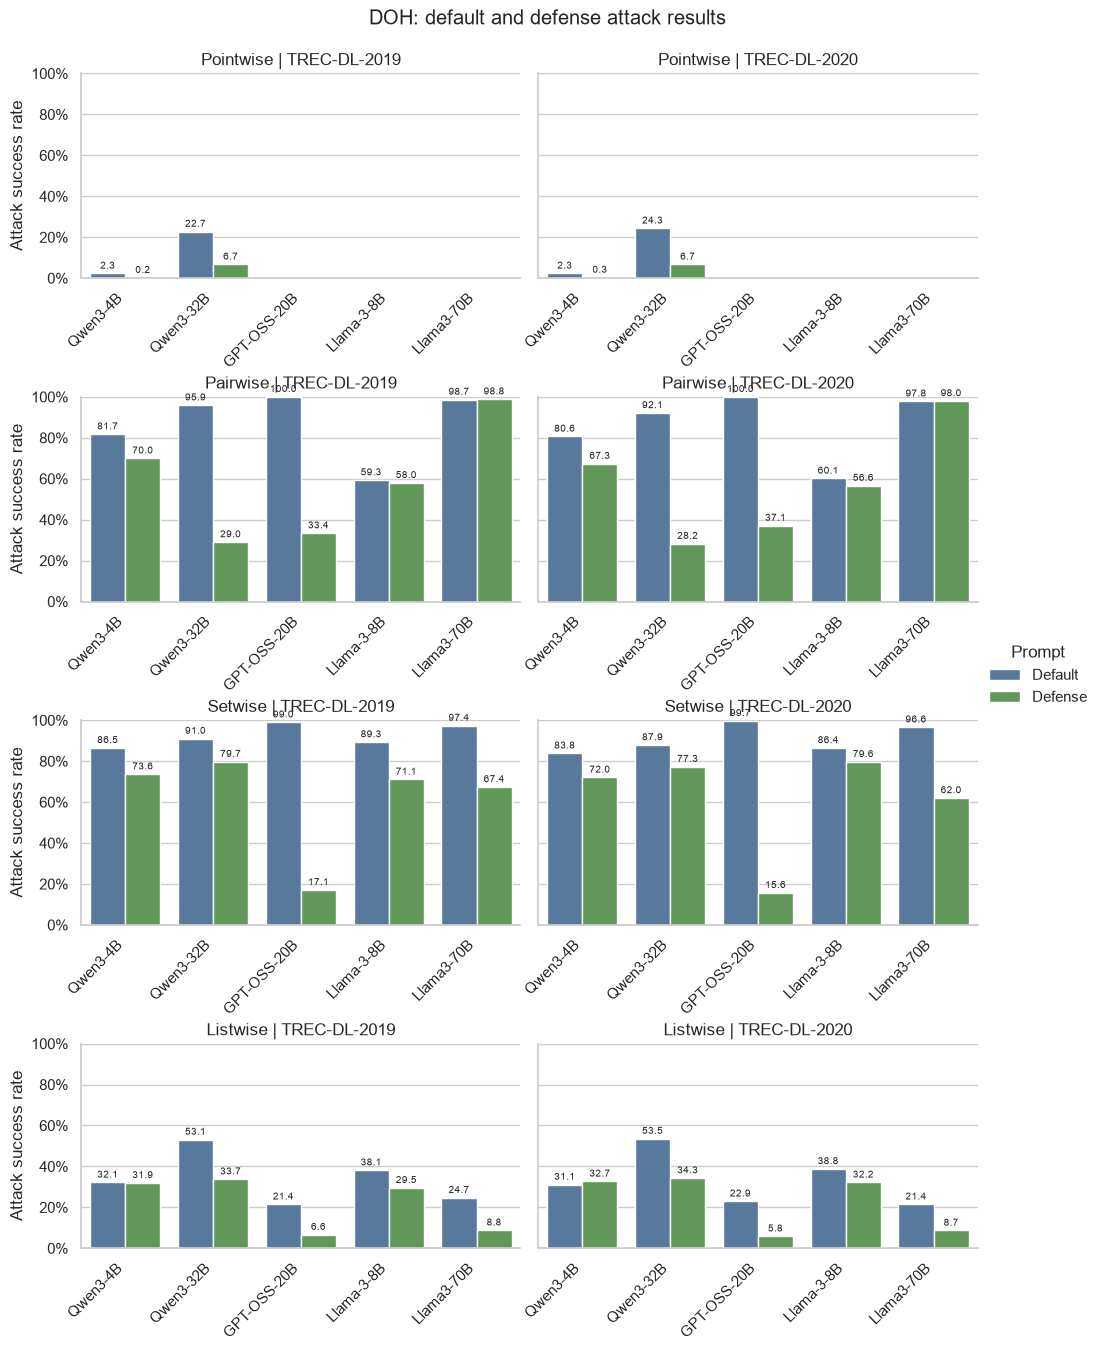

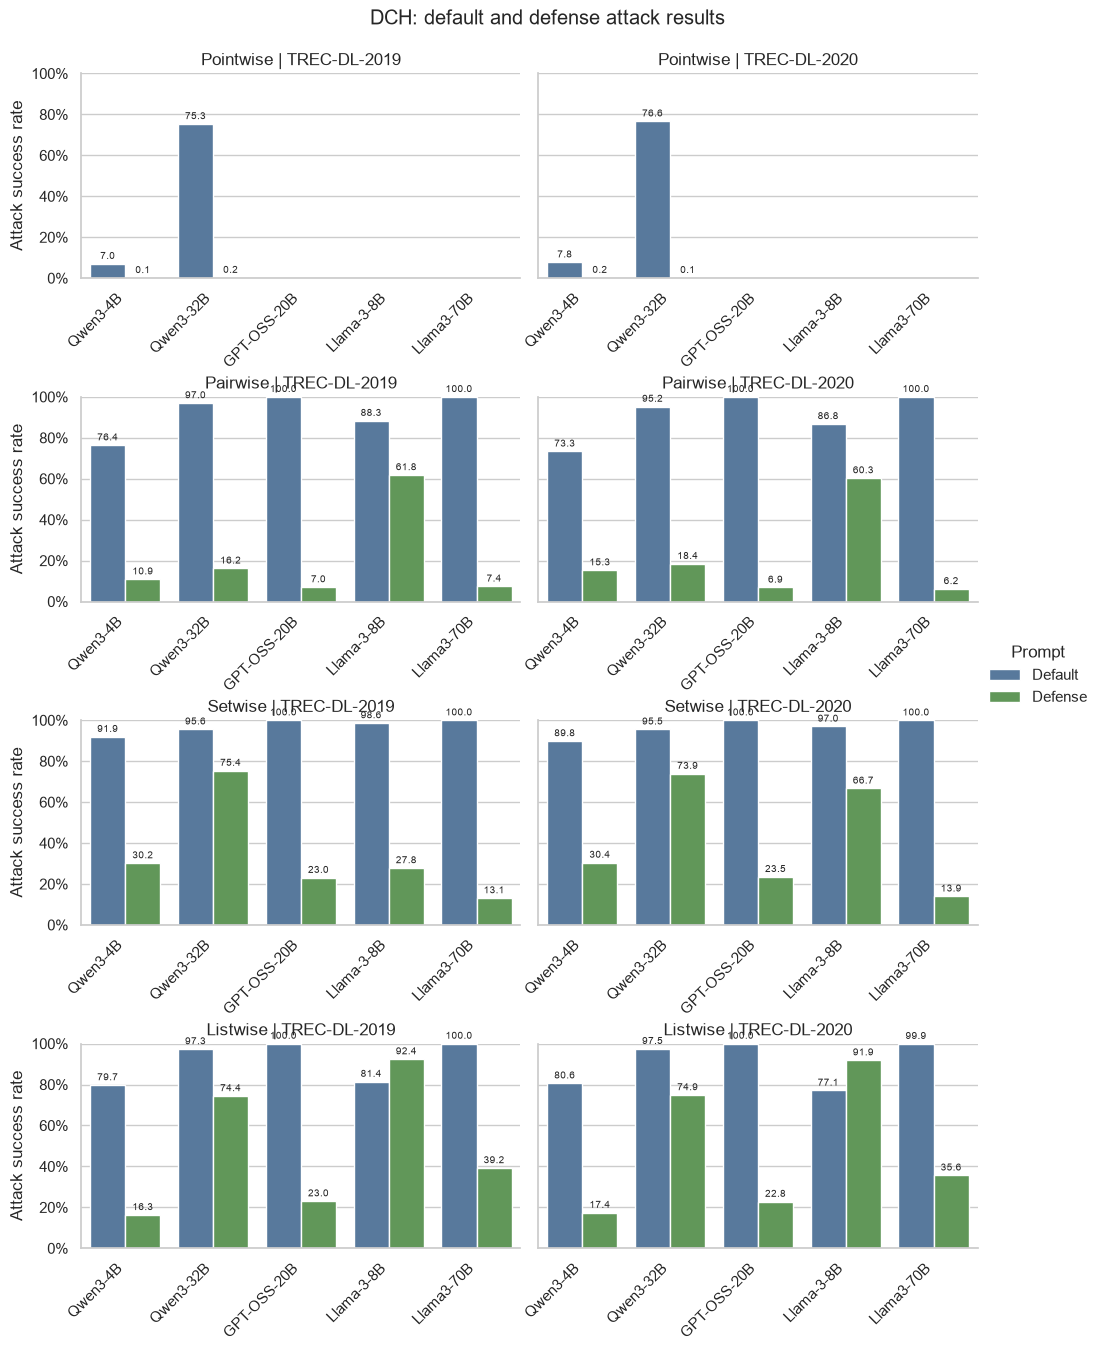

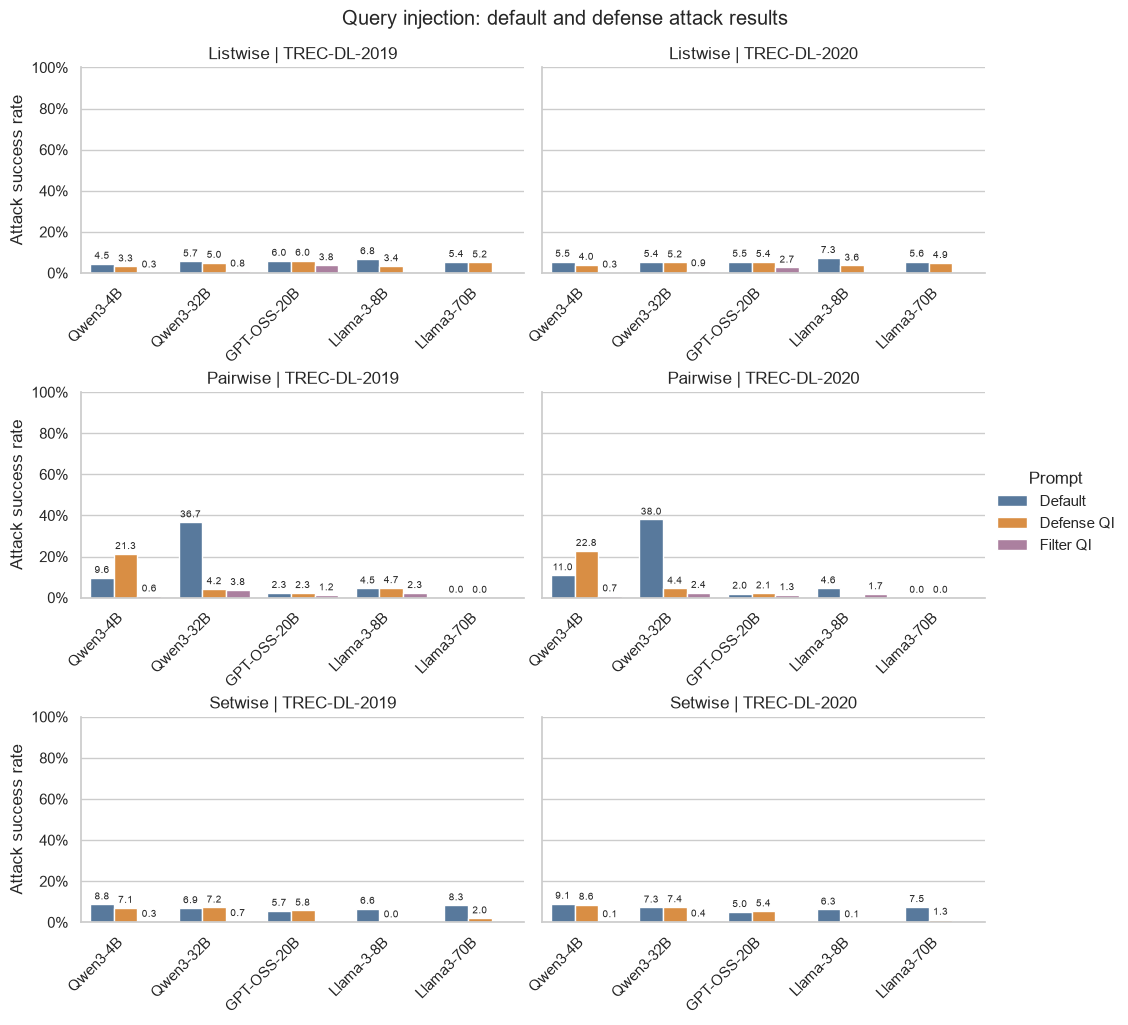

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

plot_records = []
for row in rows:
    if row['Model'] not in INCLUDED_MODELS:
        continue
    for group, display_name in GROUPS:
        for attack in ATTACKS:
            for prompt, source in MODES:
                parsed = parse_metric(row.get(column_name(group, attack, source)))
                if parsed is None:
                    continue
                rate, _success, valid = parsed
                plot_records.append(
                    {
                        'Dataset': row['Dataset'],
                        'Model': normalize_model(row['Model']),
                        'Paradigm': display_name,
                        'Attack': attack,
                        'Prompt': prompt,
                        'ASR (%)': rate,
                        'Malformed / skipped (%)': (4096 - int(valid)) / 4096 * 100,
                    }
                )

plot_data = pd.DataFrame(plot_records)
outcomes_path = root / 'Results' / 'attack_outcomes.csv'
if outcomes_path.exists():
    qi_data = pd.read_csv(outcomes_path)
    qi_data = qi_data[
        qi_data['Attack'].eq('Query injection')
        & qi_data['Prompt'].isin(['Default', 'Defense QI', 'Filter QI'])
        & qi_data['Valid attacked'].gt(0)
    ].copy()
    if not qi_data.empty:
        qi_data['Model'] = qi_data['Model'].map(normalize_model)
        qi_data = qi_data[qi_data['Model'].isin(INCLUDED_MODELS)].copy()
        qi_data['Paradigm'] = qi_data['Paradigm'].map(
            {
                'Pairwise': 'Pairwise',
                'Setwise': 'Setwise',
                'Listwise': 'Listwise',
            }
        )
        qi_data['ASR (%)'] = (
            qi_data['Attack success'] / qi_data['Valid attacked'] * 100
        )
        qi_data['Malformed / skipped (%)'] = qi_data['Discarded (%)']
        plot_data = pd.concat(
            [
                plot_data,
                qi_data[
                    [
                        'Dataset',
                        'Model',
                        'Paradigm',
                        'Attack',
                        'Prompt',
                        'ASR (%)',
                        'Malformed / skipped (%)',
                    ]
                ],
            ],
            ignore_index=True,
        )
if plot_data.empty:
    print('No attack results are available to plot.')
else:
    sns.set_theme(style='whitegrid', context='notebook')
    for attack, attack_data in plot_data.groupby('Attack', sort=False):
        prompt_order = ['Default', 'Defense QI', 'Filter QI'] if attack == 'Query injection' else ['Default', 'Defense']
        chart = sns.catplot(
            data=attack_data,
            kind='bar',
            x='Model',
            y='ASR (%)',
            hue='Prompt',
            hue_order=prompt_order,
            col='Dataset',
            row='Paradigm',
            order=[model for model in INCLUDED_MODELS if model in set(attack_data['Model'])],
            palette={'Default': '#4C78A8', 'Defense': '#59A14F', 'Defense QI': '#F28E2B', 'Filter QI': '#B279A2'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('', 'Attack success rate')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle(f'{attack}: default and defense attack results', y=1.02)
        for axis in chart.axes.flat:
            for container in axis.containers:
                labels = [f'{bar.get_height():.1f}' for bar in container]
                axis.bar_label(container, labels=labels, padding=2, fontsize=7)
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelbottom=True, labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        chart.figure.subplots_adjust(hspace=0.58)
        slug = attack.lower().replace(' ', '_')
        plt.show()





## ASR with consideration of invalid attacks

These charts treat invalid or skipped attacked rankings as failed attacks. They therefore calculate ASR as successful attacks divided by all requested passages in the run. Results are separated by attack type and compare Default, Defense, and Defense QI when available.

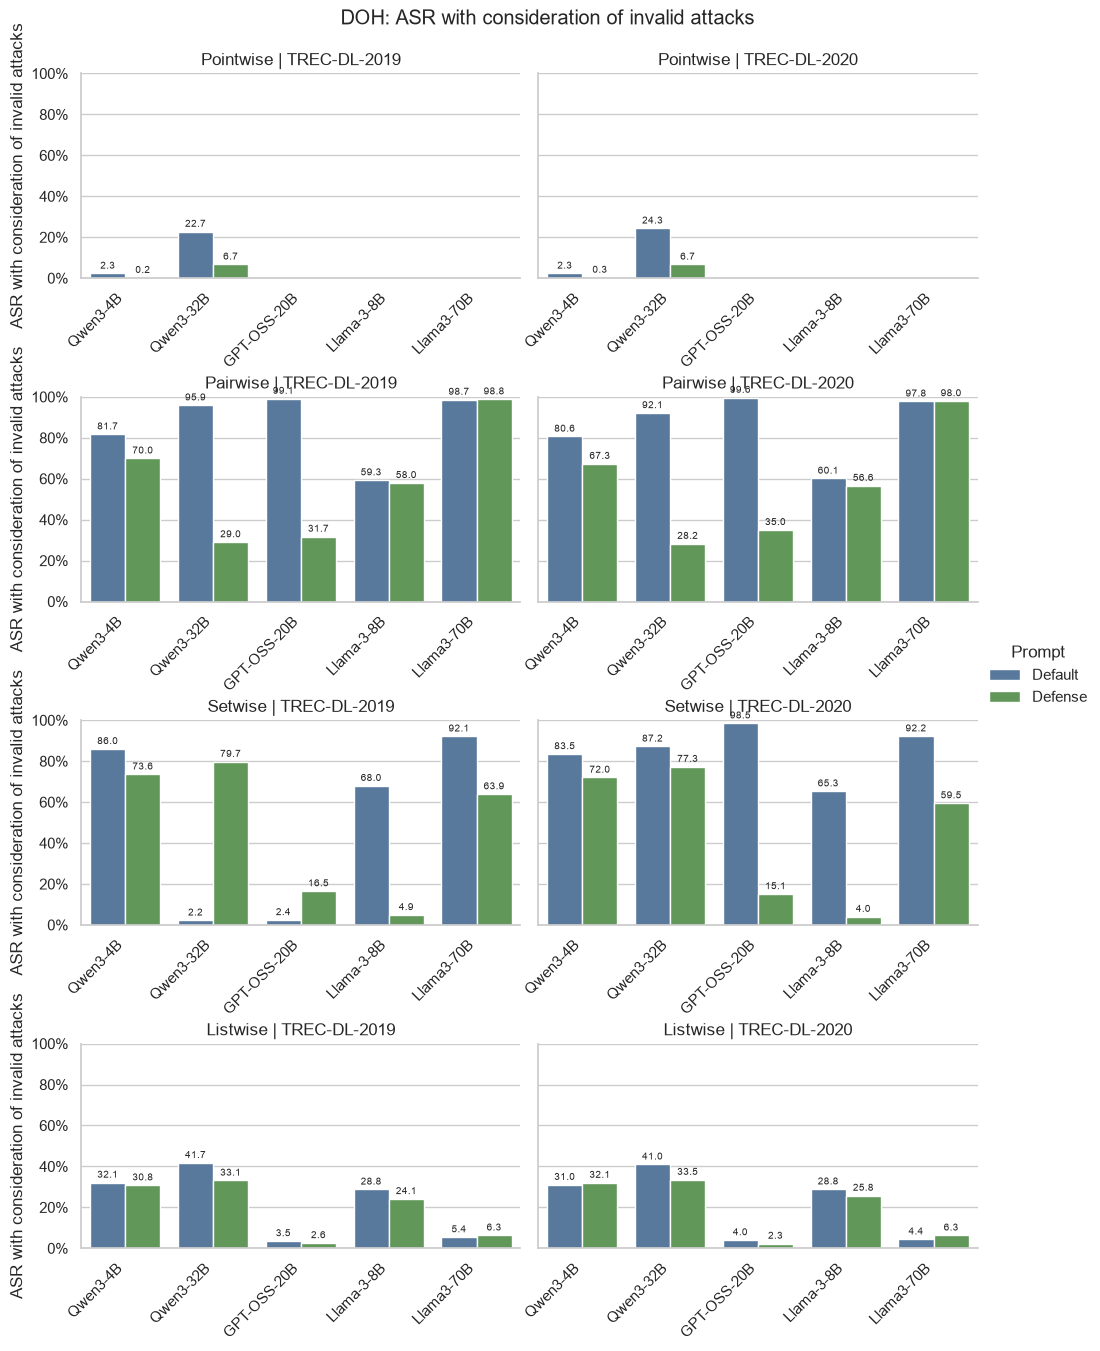

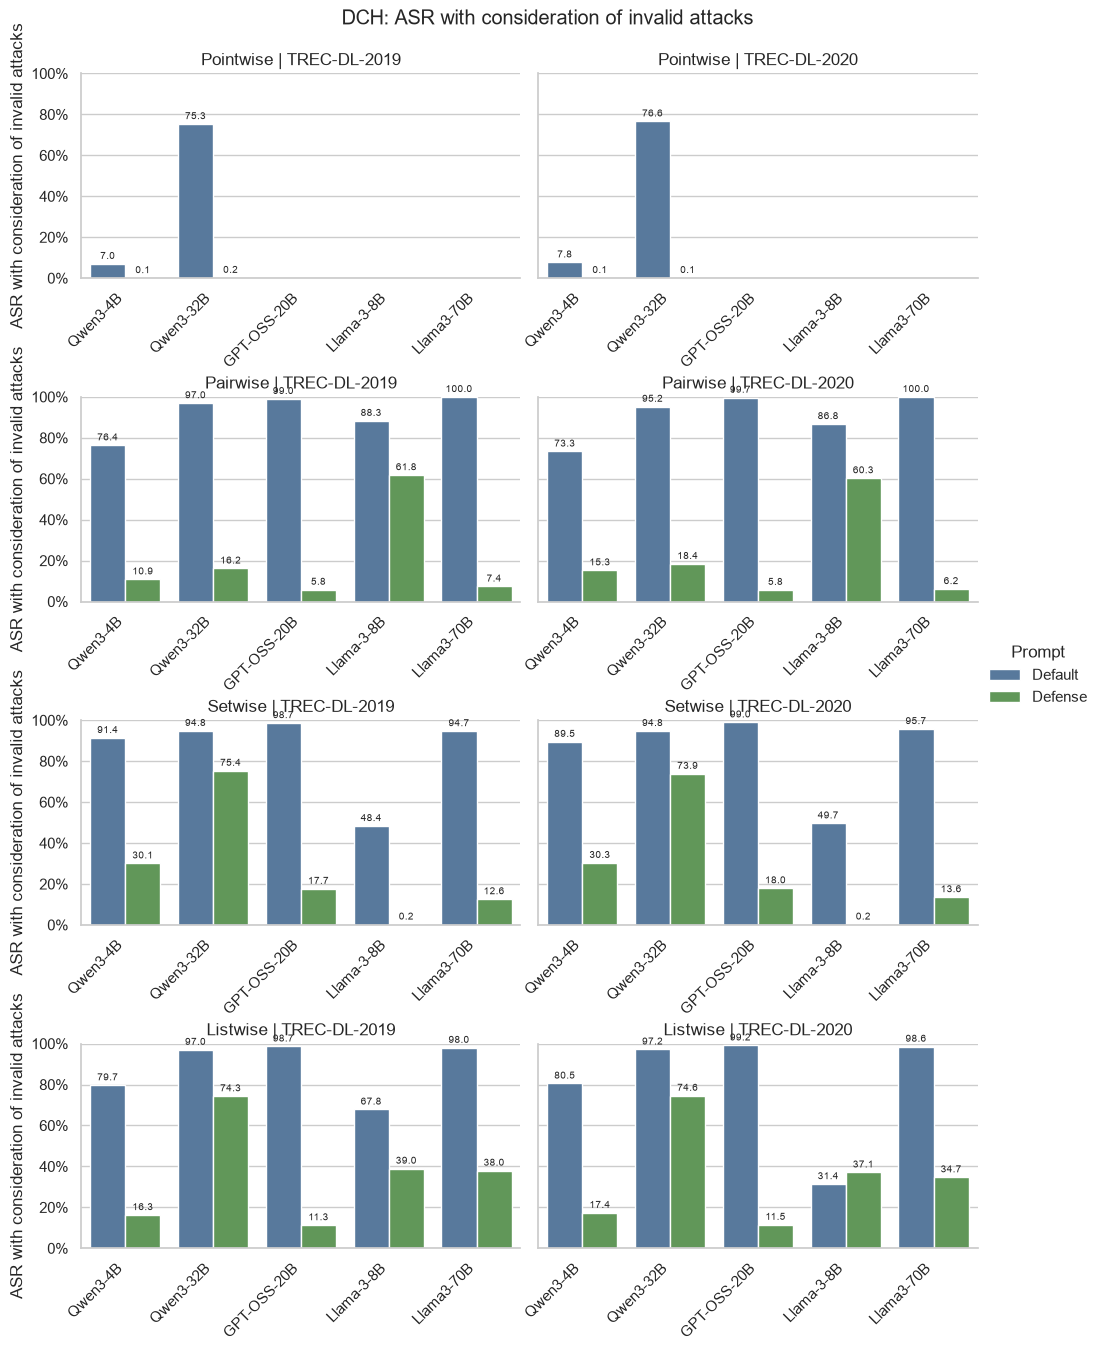

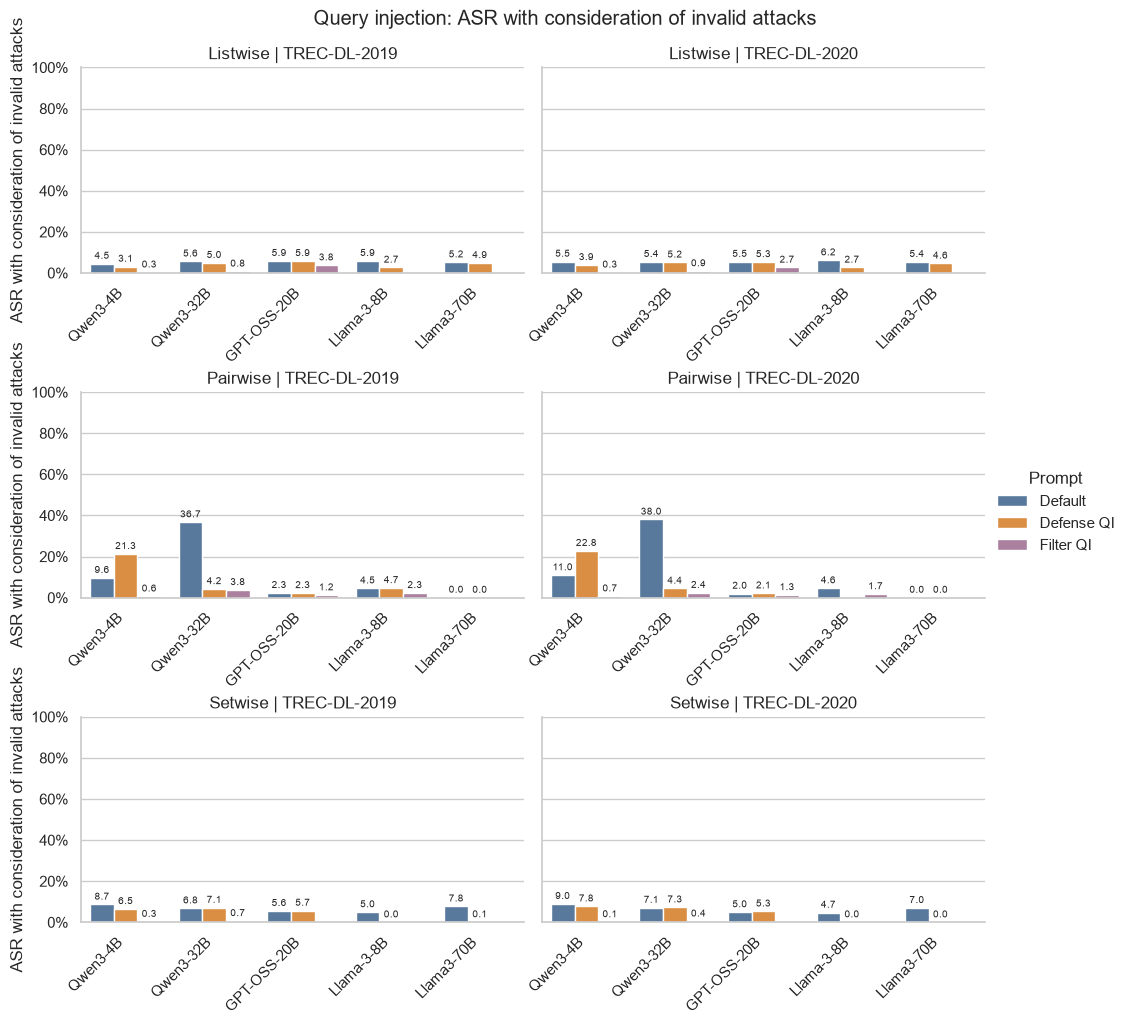

In [8]:
full_run_data = plot_data.assign(
    **{
        'ASR with invalid attacks (%)': plot_data['ASR (%)']
        * (1 - plot_data['Malformed / skipped (%)'] / 100)
    }
)

if full_run_data.empty:
    print('No attack results are available to plot.')
else:
    for attack, attack_data in full_run_data.groupby('Attack', sort=False):
        prompt_order = ['Default', 'Defense QI', 'Filter QI'] if attack == 'Query injection' else ['Default', 'Defense']
        chart = sns.catplot(
            data=attack_data,
            kind='bar',
            x='Model',
            y='ASR with invalid attacks (%)',
            hue='Prompt',
            hue_order=prompt_order,
            col='Dataset',
            row='Paradigm',
            order=[model for model in INCLUDED_MODELS if model in set(attack_data['Model'])],
            palette={'Default': '#4C78A8', 'Defense': '#59A14F', 'Defense QI': '#F28E2B', 'Filter QI': '#B279A2'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('', 'ASR with consideration of invalid attacks')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle(f'{attack}: ASR with consideration of invalid attacks', y=1.02)
        for axis in chart.axes.flat:
            for container in axis.containers:
                labels = [
                    f'{bar.get_height():.1f}'
                    for bar in container
                ]
                axis.bar_label(container, labels=labels, padding=2, fontsize=7)
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelbottom=True, labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        chart.figure.subplots_adjust(hspace=0.58)
        slug = attack.lower().replace(' ', '_')
        plt.show()



## Close attack (Query Injection)

Close attack is reported separately because it uses closer relevance grades: 3/2 for pairwise and 3/2/2/2 for setwise and listwise. It is therefore not directly comparable with the standard 3/0 DOH/DCH table above. Run `Results/update_close_attack_table.py` after adding completed close-attack output files to refresh the source CSV.


In [9]:
close_attack_path = root / 'Results' / 'close_attack_table.csv'
if not close_attack_path.exists():
    print('No close-attack summary found. Run Results/update_close_attack_table.py first.')
else:
    close_data = pd.read_csv(close_attack_path)
    close_data['Prompt'] = close_data['Prompt'].replace({
        'standard': 'Default',
        'defense': 'Defense',
        'defense_qi': 'Defense QI',
        'filter_qi': 'Filter QI',
    })
    close_data['Model'] = close_data['Model'].map(normalize_model)
    close_data = close_data[close_data['Model'].isin(INCLUDED_MODELS)].copy()
    close_data['Paradigm'] = close_data['Paradigm'].str.title()
    close_data['Success %'] = pd.to_numeric(close_data['Success %'])
    close_data['Valid'] = pd.to_numeric(close_data['Valid'])
    close_data['Malformed / skipped (%)'] = (4096 - close_data['Valid']) / 4096 * 100

    display(close_data.sort_values(['Dataset', 'Paradigm', 'Model', 'Prompt']))

    close_plot_data = close_data[close_data['Valid'].gt(0)].copy()
    if close_plot_data.empty:
        print('No valid close-attack results are available to plot.')
    else:
        prompt_order = ['Default', 'Defense', 'Defense QI', 'Filter QI']
        chart = sns.catplot(
            data=close_plot_data,
            kind='bar',
            x='Model',
            y='Success %',
            hue='Prompt',
            hue_order=prompt_order,
            col='Dataset',
            row='Paradigm',
            order=[model for model in INCLUDED_MODELS if model in set(close_plot_data['Model'])],
            palette={'Default': '#4C78A8', 'Defense': '#59A14F', 'Defense QI': '#F28E2B', 'Filter QI': '#B279A2'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('Model', 'Attack success rate')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle('Close attack (Query Injection): default and defense results', y=1.02)
        for axis in chart.axes.flat:
            for container in axis.containers:
                labels = [f'{bar.get_height():.1f}' for bar in container]
                axis.bar_label(container, labels=labels, padding=2, fontsize=7)
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelbottom=True, labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        chart.figure.subplots_adjust(hspace=0.58)
        plt.show()



,Dataset,Model,Paradigm,Prompt,Success %,Success,Valid,Requested,Malformed / skipped (%)


No valid close-attack results are available to plot.
